# Reviewers' Responses

 1. Normalization assumption
 2. Comparing normalized and non-normalized redults
 3. Pre-registeration MBF values
 4. Alternative approaches?

In [2]:
import glob
import os
import vtk
vtk.vtkObject.GlobalWarningDisplayOff()
import sys
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import kruskal, wilcoxon, linregress, norm, fisher_exact, mannwhitneyu
from scipy.ndimage import gaussian_filter
from scipy.interpolate import make_interp_spline, BSpline
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from vtk.util.numpy_support import vtk_to_numpy, numpy_to_vtk

sys.path.append(os.path.pardir)
from utilities import ReadVTUFile, ThresholdInBetween, ThresholdByUpper, LargestConnectedRegion, WriteVTUFile


In [3]:
plt.rcParams['font.family'] = 'Helvetica'#'Times New Roman'
plt.rcParams['mathtext.fontset'] = 'custom'
plt.rcParams['mathtext.rm'] = 'Helvetica' #'Times New Roman'
font1 = {'color':'black','size':23, 'family':'Helvetica'}
font2 = {'color':'black','size':20, 'family':'Helvetica'}

color1 = '#1B7F79' #deep teal
color2 = '#E07B39' #soft orange
color3 = '#4C6EF5' # Slate Blue
color4 = '#E0A458' # Amber Gold
color5 = '#2F3E46' # Muted Navy Blue
color6 = '#7A8A8F' # Warm Slate Gray
color7 = '#8B6F9C' # Dusty Purple
color8 = '#8FA98C' # Olive Green (Desaturated)
color9 = '#E6D8B8' # Warm Beige
color10 = '#4D4D4D' # Dark Gray
color11 = '#009E73' # Bluish Green

color_set1 = ['#8FBCBB', '#BF616A', '#5E81AC']

In [4]:
path = "/Volumes/T7_Research/CABG/05_PrePostCABG/InterPatientStudy"
metadata = glob.glob(f"{path}/*.xlsx")
print(metadata)
VTUFiles = sorted(glob.glob(f"{path}/*.vtu"))
TerritoryLabels = sorted(glob.glob(f"{path}/*.dat"))
print(VTUFiles)

PatientMetadata = pd.read_excel(metadata[1], dtype={'column_name': str})

nr_path = '/Volumes/T7_Research/CABG/05_PrePostCABG/NonRegistered'
VTKFiles = sorted(glob.glob(f"{nr_path}/*.vtk"))

['/Volumes/T7_Research/CABG/05_PrePostCABG/InterPatientStudy/~$PatientMetadata.xlsx', '/Volumes/T7_Research/CABG/05_PrePostCABG/InterPatientStudy/PatientMetadata.xlsx']
['/Volumes/T7_Research/CABG/05_PrePostCABG/InterPatientStudy/SU03A_MBF_Territories.vtu', '/Volumes/T7_Research/CABG/05_PrePostCABG/InterPatientStudy/SU03B_MBF_Territories.vtu', '/Volumes/T7_Research/CABG/05_PrePostCABG/InterPatientStudy/SU04A_MBF_Territories.vtu', '/Volumes/T7_Research/CABG/05_PrePostCABG/InterPatientStudy/SU04B_MBF_Territories.vtu', '/Volumes/T7_Research/CABG/05_PrePostCABG/InterPatientStudy/SU06A_MBF_Territories.vtu', '/Volumes/T7_Research/CABG/05_PrePostCABG/InterPatientStudy/SU06B_MBF_Territories.vtu', '/Volumes/T7_Research/CABG/05_PrePostCABG/InterPatientStudy/SU07A_MBF_Territories.vtu', '/Volumes/T7_Research/CABG/05_PrePostCABG/InterPatientStudy/SU07B_MBF_Territories.vtu', '/Volumes/T7_Research/CABG/05_PrePostCABG/InterPatientStudy/SU10A_MBF_Territories.vtu', '/Volumes/T7_Research/CABG/05_PrePostC

In [5]:
print(PatientMetadata)

   patient-id stenosis tag   graft severity-anatomical (%)  is-ischemic  \
0        SU03         Diag  Radial                     100         True   
1        SU03          LAD    LIMA                      70         True   
2        SU03          RCA     SVG                     100         True   
3        SU04          LAD    LIMA                      80         True   
4        SU04          LCx  Radial                      80         True   
..        ...          ...     ...                     ...          ...   
70       VA08          LCx     SVG                       n         True   
71       VA08          RCA     SVG                       n         True   
72       VA20          LAD    LIMA                       n         True   
73       VA20          LCx     SVG                       n         True   
74       VA20          RCA     SVG                       n         True   

    cutoff   NG Note  graft-stenosis  
0       90   IM  NaN               0  
1       90  OM1  NaN 

In [6]:
patient_ids = sorted(set(PatientMetadata["patient-id"]))
print(patient_ids)

['SU03', 'SU04', 'SU06', 'SU07', 'SU10', 'SU11', 'SU13', 'SU14', 'SU16', 'SU21', 'SU23', 'SU24', 'SU25', 'SU26', 'SU27', 'SU28', 'SU30', 'SU33', 'SU34', 'VA02', 'VA04', 'VA06', 'VA08', 'VA10', 'VA13', 'VA14', 'VA16', 'VA20']


In [7]:
def ReadLabels(InputLabels, TerritoryTag):
    MBF_Labels = {}
    for tag in TerritoryTag:
        MBF_Labels[tag] =  []
    MBF_Labels["Non-grafted\nstenosis>50%"] = []
    MBF_Labels["Non-grafted\nstenosis<50%"] = []
    with open(InputLabels, "r") as ifile:
        for i, LINE in enumerate(ifile):
            if i == 0: 
                continue
            line = LINE.strip().split()
            label = line[1]
            id_value = int(line[0])
            found = False

            for key in TerritoryTag:
                if key in label: 
                    MBF_Labels[key].append(id_value)
                    found = True
            
            if not found:
                if "NG" in label:
                    MBF_Labels["Non-grafted\nstenosis>50%"].append(id_value)
                    found = True
                else:
                    MBF_Labels["Non-grafted\nstenosis<50%"].append(id_value)

    MBF_Labels = {k.replace('post_', ''):v for k,v in MBF_Labels.items() if len(v)>0}
    
    return MBF_Labels

def robust_mode(data, bins=50):
    counts, bin_edges = np.histogram(data, bins=bins)
    max_bin_index = np.argmax(counts)
    mode_value = (bin_edges[max_bin_index] + bin_edges[max_bin_index + 1]) / 2
    return mode_value

def Normalize(MBF, method="mode", cutoff = 50):
    for i in range(MBF.GetPointData().GetNumberOfArrays()):
        arrayname_ = MBF.GetPointData().GetArrayName(i)
        if 'scalars' in arrayname_.lower():
            ArrayName = arrayname_
    
    ScalarArray = vtk_to_numpy(MBF.GetPointData().GetArray(ArrayName))
    #HealthyMyo = LargestConnectedRegion(ThresholdByUpper(MBF, ArrayName, cutoff))
    HealthyMyo = LargestConnectedRegion(ThresholdInBetween(MBF, ArrayName, np.percentile(ScalarArray,10), np.percentile(ScalarArray,90)))
    #HealthyMyo = LargestConnectedRegion(ThresholdByUpper(HealthyMyo, ArrayName, cutoff))
    ScalarArray_healthy = vtk_to_numpy(HealthyMyo.GetPointData().GetArray(ArrayName))
    
    if method == "mode": # Histogram Analysis
        # Using Freedman-Diaconis Rule to calculate the number of bins based on IQR
        IQR = np.percentile(ScalarArray_healthy, 75) - np.percentile(ScalarArray_healthy, 25)
        bin_width = 2*IQR/(len(ScalarArray_healthy))**(1/3)
        MBF_range = np.max(ScalarArray_healthy) - np.min(ScalarArray_healthy)
        bins = int(MBF_range/bin_width)
        ref_MBF = robust_mode(ScalarArray_healthy, bins)
    elif method == "median":
        ref_MBF = np.median(ScalarArray_healthy)
    elif method == "mean":
        ref_MBF = np.mean(ScalarArray_healthy)
    elif method == "classic":
        ref_MBF = np.percentile(ScalarArray, 75)
    elif method == "zscore":
        q1, q2, q3 = np.percentile(ScalarArray_healthy, [25, 50, 75])
        IndexMBFArray = (ScalarArray - q2)/(q3 - q1)
        IndexMBFArray = gaussian_filter(IndexMBFArray, sigma=1)
        IndexMBF = numpy_to_vtk(IndexMBFArray)
        IndexMBF.SetName("IndexMBF")
        MBF.GetPointData().AddArray(IndexMBF)

        return MBF
    else:
        ref_MBF = np.percentile(ScalarArray_healthy, 75)

    IndexMBFArray = ScalarArray/ref_MBF
    #IndexMBFArray = gaussian_filter(IndexMBFArray, sigma=1)
    IndexMBF = numpy_to_vtk(IndexMBFArray)
    IndexMBF.SetName("IndexMBF")
    MBF.GetPointData().AddArray(IndexMBF)

    return MBF

def GetVolume(Grid):
    Volume = 0
    for i in range(Grid.GetNumberOfCells()):
        voxel = Grid.GetCell(i)
        cell_bounds = voxel.GetBounds()
        Volume += abs(cell_bounds[0] - cell_bounds[1]) * abs(cell_bounds[2] - cell_bounds[3]) * abs(cell_bounds[4] - cell_bounds[5])
    
    return Volume

def CollectMBFData(MBF, Labels):
    for i in range(MBF.GetPointData().GetNumberOfArrays()):
            arrayname_ = MBF.GetPointData().GetArrayName(i)
            if 'scalars' in arrayname_.lower():
                ScalarArray = arrayname_

    AbsMBFData = {}
    #IndexMBFData = {}
    for key in Labels.keys():
        AbsMBFData[key] = np.array([])
        #IndexMBFData[key] = np.array([])
        for i in Labels[key]:
            territory_ = ThresholdInBetween(MBF, "TerritoryMaps", i, i)
            MBF_ = vtk_to_numpy(territory_.GetPointData().GetArray(ScalarArray))
            #iMBF_ = vtk_to_numpy(territory_.GetPointData().GetArray("IndexMBF"))
            AbsMBFData[key] = np.append(AbsMBFData[key], MBF_)
            #IndexMBFData[key] = np.append(IndexMBFData[key], iMBF_)
    

    return AbsMBFData#, IndexMBFData

def GetRegionVolume(MBF, Labels, key):
    volume = 0

    for i in Labels[key]:
        territory_ = ThresholdInBetween(MBF, "TerritoryMaps", i, i)
        volume += GetVolume(territory_)
    
    return volume

def BoxPlot(DataFrame):
    plt.figure(figsize=(8, 5))
    ax = sns.boxplot(x='Territories', y='MBF', hue='Type', data= DataFrame, showfliers=False, palette={'A':'skyblue', 'B':'salmon'})

    ax.set_ylabel("Index MBF", fontsize = 20)
    ax.tick_params(axis='x', rotation=10, labelsize=15)
    ax.legend(loc = 'upper left')
    plt.tight_layout()
    plt.show()

def ViolinPlot(DataFrame):
    plt.figure(figsize=(7.5, 5.5))

    sns.violinplot(x='Territories', y='MBF', hue='Type', data = DataFrame, split=True, inner = 'quartiles', bw_adjust = 10, common_norm=True, linewidth=2.5, fill= False, gap=.1, palette={'Baseline':color1, 'Follow-up':color2})

    plt.ylabel("Myocardial Blood Flow\n(mL/min/100mL)", fontsize = 23)
    plt.tick_params(axis= 'x', labelsize = 18)
    plt.xticks(fontsize = 20, rotation=90)
    plt.yticks(fontsize = 18)
    #plt.xlabel("Group")
    plt.legend(fontsize = 16, loc="upper left")
    plt.ylim([-200, 800])
    plt.show()

def MapNongrafted(meanA, meanB, stdA, stdB, DataA):
    return meanB + (stdB/stdA)*(DataA - meanA)

def Map3DVolume(meanA, meanB, stdA, stdB, VolumeA):
    for i in range(VolumeA.GetPointData().GetNumberOfArrays()):
            arrayname_ = VolumeA.GetPointData().GetArrayName(i)
            if 'scalars' in arrayname_.lower():
                ScalarArray = arrayname_

    ScalarData = vtk_to_numpy(VolumeA.GetPointData().GetArray(ScalarArray))
    ScalarData_Mapped = numpy_to_vtk(MapNongrafted(meanA, meanB, stdA, stdB, ScalarData))
    MappedScalarArrayName = "MappedScalar"
    ScalarData_Mapped.SetName(MappedScalarArrayName)
    VolumeA.GetPointData().AddArray(ScalarData_Mapped)

    return VolumeA

def ReturnMedianMBF(Volume):
    for i in range(Volume.GetPointData().GetNumberOfArrays()):
        arrayname_ = Volume.GetPointData().GetArrayName(i)
        if 'scalars' in arrayname_.lower():
            ScalarArray = arrayname_

    ScalarData = vtk_to_numpy(Volume.GetPointData().GetArray(ScalarArray))
    return np.median(ScalarData)

def WilcoxonTest(array1, array2):
    w_value, p_value = wilcoxon(array1, array2)
    print("Wilcoxon test statistics: ", w_value)
    print("p-value: ", p_value)
    print("number of datapoints:", len(array1))

    if p_value < 0.05:
        print("Reject the null hypothesis: There is a significant difference between the two samples.")
    else:
        print("Fail to reject the null hypothesis: There is no significant difference between the two samples.")

    return p_value


In [8]:
print(PatientMetadata[PatientMetadata['patient-id'] == 'SU03']['stenosis tag'])

0    Diag
1     LAD
2     RCA
Name: stenosis tag, dtype: str


In [9]:
print(PatientMetadata[PatientMetadata['patient-id'] == 'SU03'])

  patient-id stenosis tag   graft severity-anatomical (%)  is-ischemic  \
0       SU03         Diag  Radial                     100         True   
1       SU03          LAD    LIMA                      70         True   
2       SU03          RCA     SVG                     100         True   

   cutoff   NG Note  graft-stenosis  
0      90   IM  NaN               0  
1      90  OM1  NaN               0  
2      90    n  NaN               0  


In [10]:
a = np.array([-1, -2, -3, 0, 1, 2, 3])
np.sum(a < 0)

np.int64(3)

## Non-grafted regions before and after normalization

Non-grafted stenosis>50%
Non-grafted
stenosis<50%


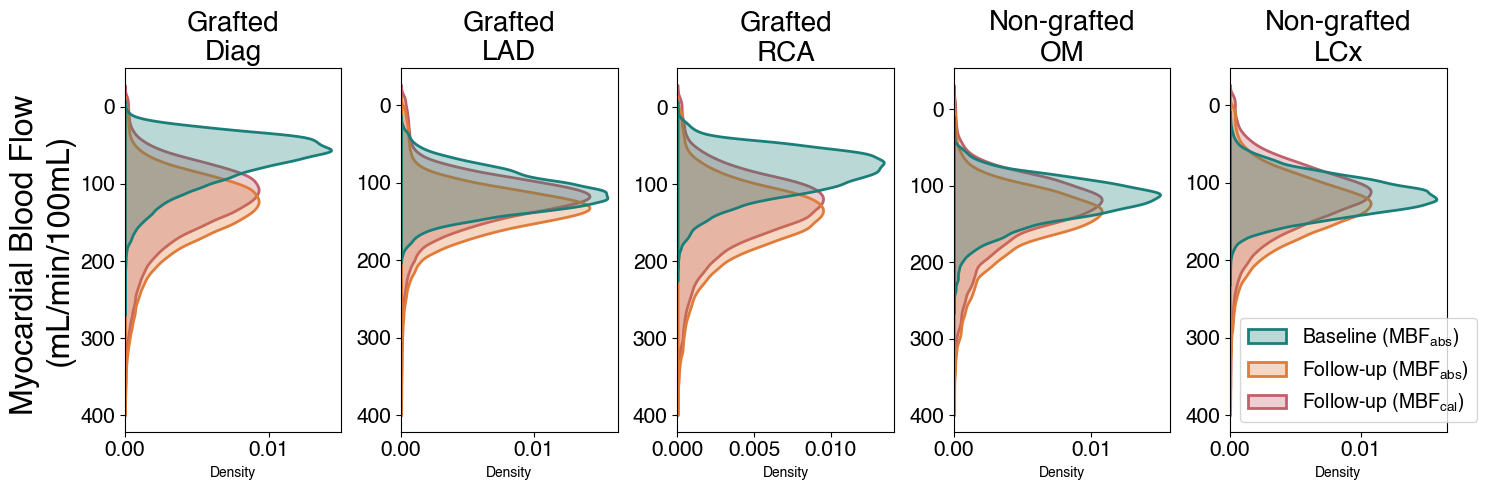

In [11]:
def ShiftMBF(refA, refB, DataA):
    return DataA - (refA - refB)

plt.rcParams['legend.fontsize'] = 14
patient_id = 'SU03'

palette = {
    'Baseline ($\\mathrm{MBF_{abs}}$)': '#1B7F79',
    'Follow-up ($\\mathrm{MBF_{abs}}$)': '#E07B39',
    'Follow-up ($\\mathrm{MBF_{cal}}$)': '#BF616A',
}

tags = list(PatientMetadata[PatientMetadata['patient-id'] == patient_id]['stenosis tag'])
ischemia = list(PatientMetadata[PatientMetadata['patient-id'] == patient_id]['is-ischemic'])
TerritoryTags = [f'post_{tag}' for tag in tags]

for file in TerritoryLabels:
    if patient_id in os.path.basename(os.path.splitext(file)[0]):
        LabelFile = file
MBF_Labels = ReadLabels(LabelFile, TerritoryTags)


for file in VTUFiles:
    if f"{patient_id}A" in os.path.basename(os.path.splitext(file)[0]):
        MBF_A = ReadVTUFile(file)
    elif f"{patient_id}B" in os.path.basename(os.path.splitext(file)[0]):
        MBF_B = ReadVTUFile(file)

AbsMBFData_A = CollectMBFData(MBF_A, MBF_Labels)
AbsMBFData_B = CollectMBFData(MBF_B, MBF_Labels)


data = pd.DataFrame({"MBF": [], "Territories": [], "Type": []})
dataMapped = pd.DataFrame({"MBF": [], "Territories": [], "Type": []})
t = "Non-grafted\nstenosis<50%"
array_A = AbsMBFData_A[t]
ref_A = np.median(array_A)
# mean_A = np.mean(array_A)
# std_A = np.std(array_A)
array_B = AbsMBFData_B[t]
ref_B = np.median(array_B)
# mean_B = np.mean(array_B)
# std_B = np.std(array_B)

# ref_A = np.percentile(MBF_Array_A, 50)
# ref_B = np.percentile(MBF_Array_B, 50)

# Mapping using z-score of the nongrafted
# MBF_Array_B_mapped = ShiftMBF(ref_B, ref_A, array_B) #
fig, axes = plt.subplots(1, 5, figsize=(15, 5))

for i, t in enumerate(tags):
    array_A = AbsMBFData_A[t]
    array_B = AbsMBFData_B[t]
    array_A_mapped = ShiftMBF(ref_B, ref_A, array_B)
    data = pd.DataFrame({
        "MBF":np.concatenate([array_A, array_B, array_A_mapped]),
        "Label": ['Baseline ($\\mathrm{MBF_{abs}}$)'] * len(array_A) + 
                ["Follow-up ($\\mathrm{MBF_{abs}}$)"] * len(array_B) + 
                ["Follow-up ($\\mathrm{MBF_{cal}}$)"] * len(array_A_mapped)
    })


    sns.kdeplot(data=data, y="MBF", hue=data['Label'].tolist(),
                fill=True, common_norm=False, palette=palette,
            alpha=.3, linewidth=2, clip=(-100, 400), ax=axes[i], legend=False)
    
    axes[i].set_title(f"Grafted\n{t}", fontdict=font2)
    # ax.set_xlabel("Myocardial Blood Flow \n(mL/min/100mL)", fontsize = 23)
    # ax.set_ylabel("Density", fontsize = 23)
    #ax.legend()
    #plt.title(f"Patient {patient_id}")
    #plt.xlim((-100, 450))
    #plt.ylim((0, 0.015))
    plt.xticks(fontsize=15)
    plt.yticks(fontsize=15)
    plt.tight_layout()
    #plt.show()

t = "Non-grafted\nstenosis>50%"
print(t.replace("\n", " "))

if t in MBF_Labels.keys():
    array_A = AbsMBFData_A[t]
    array_B = AbsMBFData_B[t]
    array_A_mapped = ShiftMBF(ref_B, ref_A, array_B)
    
    data = pd.DataFrame({
        "MBF":np.concatenate([array_A, array_B, array_A_mapped]),
        "Label": ['Baseline ($\\mathrm{MBF_{abs}}$)'] * len(array_A) + 
                ["Follow-up ($\\mathrm{MBF_{abs}}$)"] * len(array_B) + 
                ["Follow-up ($\\mathrm{MBF_{cal}}$)"] * len(array_A_mapped)
    })

    
    sns.kdeplot(data=data, y="MBF", hue=data['Label'].tolist(),
                fill=True, common_norm=False, palette=palette,
            alpha=.3, linewidth=2, clip=(-100, 400), ax=axes[i+1], legend=False)
    
    axes[i+1].set_title("Non-grafted\nOM", fontdict=font2)
    #ax.set_xlabel("Myocardial Blood Flow \n(mL/min/100mL)", fontsize = 23)
    #ax.set_ylabel("Density", fontsize = 23)
    #ax.legend()
    #plt.title(f"Patient {patient_id}")
    #plt.xlim((-100, 450))
    #plt.ylim((0, 0.015))
    plt.xticks(fontsize=15)
    plt.yticks(fontsize=15)
    plt.tight_layout()
    #plt.show()

t = "Non-grafted\nstenosis<50%"
print(t)
array_A = AbsMBFData_A[t]
array_B = AbsMBFData_B[t]
array_A_mapped = ShiftMBF(ref_B, ref_A, array_B)
data = pd.DataFrame({
    "MBF":np.concatenate([array_A, array_B, array_A_mapped]),
    "Label": ['Baseline ($\\mathrm{MBF_{abs}}$)'] * len(array_A) + 
            ["Follow-up ($\\mathrm{MBF_{abs}}$)"] * len(array_B) + 
            ["Follow-up ($\\mathrm{MBF_{cal}}$)"] * len(array_A_mapped)
})


sns.kdeplot(data=data, y="MBF", hue=data['Label'].tolist(),
                fill=True, common_norm=False, palette=palette,
            alpha=.3, linewidth=2, clip=(-100, 400), ax=axes[i+2])
#t = t.replace("\n", " ")
axes[i+2].set_title("Non-grafted\nLCx", fontdict=font2)
# ax.set_xlabel("Myocardial Blood Flow \n(mL/min/100mL)", fontsize = 23)
# ax.set_ylabel("Density", fontsize = 23)
#ax.legend()
#plt.title(f"Patient {patient_id}")
#plt.xlim((-100, 450))
#plt.ylim((0, 0.015))
axes[0].set_ylabel("Myocardial Blood Flow \n(mL/min/100mL)", fontsize = 23)
axes[0].tick_params(axis = 'x', labelsize=15)
axes[0].tick_params(axis = 'y', labelsize=15)
axes[0].invert_yaxis()
for i in range(1,5):
    axes[i].set_ylabel("")
    axes[i].tick_params(axis = 'x', labelsize=15)
    axes[i].tick_params(axis = 'y', labelsize=15)
    axes[i].invert_yaxis()
plt.tight_layout()
plt.show()


Non-grafted stenosis>50%
Non-grafted
stenosis<50%


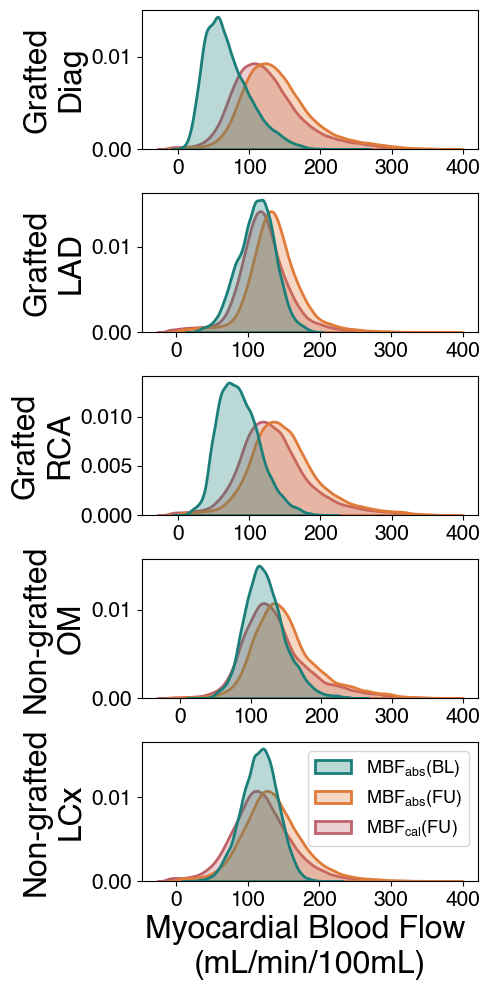

In [12]:
def ShiftMBF(refA, refB, DataA):
    return DataA - (refA - refB)

plt.rcParams['legend.fontsize'] = 13
patient_id = 'SU03'

palette = {
    '$\\mathrm{MBF_{abs}}$(BL)': '#1B7F79',
    '$\\mathrm{MBF_{abs}}$(FU)': '#E07B39',
    '$\\mathrm{MBF_{cal}}$(FU)': '#BF616A',
}

tags = list(PatientMetadata[PatientMetadata['patient-id'] == patient_id]['stenosis tag'])
ischemia = list(PatientMetadata[PatientMetadata['patient-id'] == patient_id]['is-ischemic'])
TerritoryTags = [f'post_{tag}' for tag in tags]

for file in TerritoryLabels:
    if patient_id in os.path.basename(os.path.splitext(file)[0]):
        LabelFile = file
MBF_Labels = ReadLabels(LabelFile, TerritoryTags)


for file in VTUFiles:
    if f"{patient_id}A" in os.path.basename(os.path.splitext(file)[0]):
        MBF_A = ReadVTUFile(file)
    elif f"{patient_id}B" in os.path.basename(os.path.splitext(file)[0]):
        MBF_B = ReadVTUFile(file)

AbsMBFData_A = CollectMBFData(MBF_A, MBF_Labels)
AbsMBFData_B = CollectMBFData(MBF_B, MBF_Labels)


data = pd.DataFrame({"MBF": [], "Territories": [], "Type": []})
dataMapped = pd.DataFrame({"MBF": [], "Territories": [], "Type": []})
t = "Non-grafted\nstenosis<50%"
array_A = AbsMBFData_A[t]
ref_A = np.median(array_A)
# mean_A = np.mean(array_A)
# std_A = np.std(array_A)
array_B = AbsMBFData_B[t]
ref_B = np.median(array_B)
# mean_B = np.mean(array_B)
# std_B = np.std(array_B)

# ref_A = np.percentile(MBF_Array_A, 50)
# ref_B = np.percentile(MBF_Array_B, 50)

# Mapping using z-score of the nongrafted
# MBF_Array_B_mapped = ShiftMBF(ref_B, ref_A, array_B) #
fig, axes = plt.subplots(5, 1, figsize=(5, 10))

for i, t in enumerate(tags):
    array_A = AbsMBFData_A[t]
    array_B = AbsMBFData_B[t]
    array_A_mapped = ShiftMBF(ref_B, ref_A, array_B)
    data = pd.DataFrame({
        "MBF":np.concatenate([array_A, array_B, array_A_mapped]),
        "Label": ['$\\mathrm{MBF_{abs}}$(BL)'] * len(array_A) + 
                ["$\\mathrm{MBF_{abs}}$(FU)"] * len(array_B) + 
                ["$\\mathrm{MBF_{cal}}$(FU)"] * len(array_A_mapped)
    })


    sns.kdeplot(data=data, x="MBF", hue=data['Label'].tolist(),
                fill=True, common_norm=False, palette=palette,
            alpha=.3, linewidth=2, clip=(-100, 400), ax=axes[i], legend=False)
    
    axes[i].set_ylabel(f"Grafted\n{t}", fontdict=font1)
    plt.xticks(fontsize=15)
    plt.yticks(fontsize=15)
    plt.tight_layout()
    axes[i].set_xlabel("")
    #plt.show()

t = "Non-grafted\nstenosis>50%"
print(t.replace("\n", " "))

if t in MBF_Labels.keys():
    array_A = AbsMBFData_A[t]
    array_B = AbsMBFData_B[t]
    array_A_mapped = ShiftMBF(ref_B, ref_A, array_B)
    
    data = pd.DataFrame({
        "MBF":np.concatenate([array_A, array_B, array_A_mapped]),
        "Label": ['$\\mathrm{MBF_{abs}}$(BL)'] * len(array_A) + 
                ["$\\mathrm{MBF_{abs}}$(FU)"] * len(array_B) + 
                ["$\\mathrm{MBF_{cal}}$(FU)"] * len(array_A_mapped)
    })

    
    sns.kdeplot(data=data, x="MBF", hue=data['Label'].tolist(),
                fill=True, common_norm=False, palette=palette,
            alpha=.3, linewidth=2, clip=(-100, 400), ax=axes[i+1], legend=False)
    
    axes[i+1].set_ylabel("Non-grafted\nOM", fontdict=font1)
    plt.xticks(fontsize=15)
    plt.yticks(fontsize=15)
    plt.tight_layout()
    axes[i+1].set_xlabel("")
    #plt.show()

t = "Non-grafted\nstenosis<50%"
print(t)
array_A = AbsMBFData_A[t]
array_B = AbsMBFData_B[t]
array_A_mapped = ShiftMBF(ref_B, ref_A, array_B)
data = pd.DataFrame({
    "MBF":np.concatenate([array_A, array_B, array_A_mapped]),
    "Label": ['$\\mathrm{MBF_{abs}}$(BL)'] * len(array_A) + 
            ["$\\mathrm{MBF_{abs}}$(FU)"] * len(array_B) + 
            ["$\\mathrm{MBF_{cal}}$(FU)"] * len(array_A_mapped)
})


sns.kdeplot(data=data, x="MBF", hue=data['Label'].tolist(),
                fill=True, common_norm=False, palette=palette,
            alpha=.3, linewidth=2, clip=(-100, 400), ax=axes[i+2])

axes[i+2].set_ylabel("Non-grafted\nLCx", fontdict=font1)
axes[4].set_xlabel("Myocardial Blood Flow \n(mL/min/100mL)", fontsize = 23)
axes[0].tick_params(axis = 'x', labelsize=15)
axes[0].tick_params(axis = 'y', labelsize=15)
for i in range(1,5):
    axes[i].tick_params(axis = 'x', labelsize=15)
    axes[i].tick_params(axis = 'y', labelsize=15)
plt.tight_layout()
plt.show()


Non-grafted
stenosis<50%


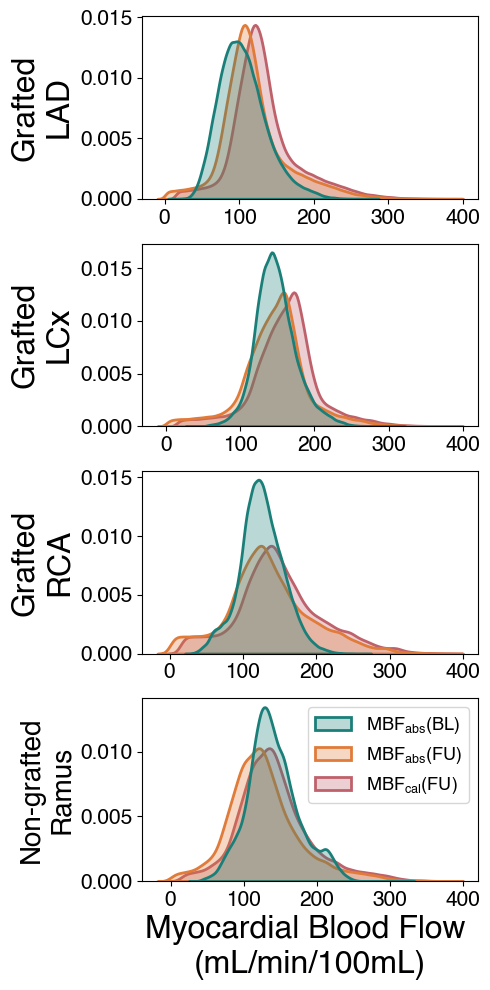

In [20]:
patient_id = 'SU13'

tags = list(PatientMetadata[PatientMetadata['patient-id'] == patient_id]['stenosis tag'])
ischemia = list(PatientMetadata[PatientMetadata['patient-id'] == patient_id]['is-ischemic'])
TerritoryTags = [f'post_{tag}' for tag in tags]

for file in TerritoryLabels:
    if patient_id in os.path.basename(os.path.splitext(file)[0]):
        LabelFile = file
MBF_Labels = ReadLabels(LabelFile, TerritoryTags)


for file in VTUFiles:
    if f"{patient_id}A" in os.path.basename(os.path.splitext(file)[0]):
        MBF_A = ReadVTUFile(file)
    elif f"{patient_id}B" in os.path.basename(os.path.splitext(file)[0]):
        MBF_B = ReadVTUFile(file)

AbsMBFData_A = CollectMBFData(MBF_A, MBF_Labels)
AbsMBFData_B = CollectMBFData(MBF_B, MBF_Labels)


data = pd.DataFrame({"MBF": [], "Territories": [], "Type": []})
dataMapped = pd.DataFrame({"MBF": [], "Territories": [], "Type": []})
t = "Non-grafted\nstenosis<50%"
array_A = AbsMBFData_A[t]
ref_A = np.median(array_A)
# mean_A = np.mean(array_A)
# std_A = np.std(array_A)
array_B = AbsMBFData_B[t]
ref_B = np.median(array_B)
# mean_B = np.mean(array_B)
# std_B = np.std(array_B)

# ref_A = np.percentile(MBF_Array_A, 50)
# ref_B = np.percentile(MBF_Array_B, 50)

# Mapping using z-score of the nongrafted
# MBF_Array_B_mapped = ShiftMBF(ref_B, ref_A, array_B) #
fig, axes = plt.subplots(4, 1, figsize=(5, 10))

for i, t in enumerate(tags):
    array_A = AbsMBFData_A[t]
    array_B = AbsMBFData_B[t]
    array_A_mapped = ShiftMBF(ref_B, ref_A, array_B)
    data = pd.DataFrame({
        "MBF":np.concatenate([array_A, array_B, array_A_mapped]),
        "Label": ['$\\mathrm{MBF_{abs}}$(BL)'] * len(array_A) + 
                ["$\\mathrm{MBF_{abs}}$(FU)"] * len(array_B) + 
                ["$\\mathrm{MBF_{cal}}$(FU)"] * len(array_A_mapped)
    })


    sns.kdeplot(data=data, x="MBF", hue=data['Label'].tolist(),
                fill=True, common_norm=False, palette=palette,
            alpha=.3, linewidth=2, clip=(-100, 400), ax=axes[i], legend=False)
    
    axes[i].set_ylabel(f"Grafted\n{t}", fontdict=font1)
    plt.xticks(fontsize=15)
    plt.yticks(fontsize=15)
    plt.tight_layout()
    axes[i].set_xlabel("")


t = "Non-grafted\nstenosis<50%"
print(t)
array_A = AbsMBFData_A[t]
array_B = AbsMBFData_B[t]
array_A_mapped = ShiftMBF(ref_B, ref_A, array_B)
data = pd.DataFrame({
    "MBF":np.concatenate([array_A, array_B, array_A_mapped]),
    "Label": ['$\\mathrm{MBF_{abs}}$(BL)'] * len(array_A) + 
            ["$\\mathrm{MBF_{abs}}$(FU)"] * len(array_B) + 
            ["$\\mathrm{MBF_{cal}}$(FU)"] * len(array_A_mapped)
})


sns.kdeplot(data=data, x="MBF", hue=data['Label'].tolist(),
                fill=True, common_norm=False, palette=palette,
            alpha=.3, linewidth=2, clip=(-100, 400), ax=axes[i+1])
#t = t.replace("\n", " ")
axes[i+1].set_ylabel("Non-grafted\nRamus", fontdict=font2)
axes[3].set_xlabel("Myocardial Blood Flow \n(mL/min/100mL)", fontsize = 23)
axes[0].tick_params(axis = 'x', labelsize=15)
axes[0].tick_params(axis = 'y', labelsize=15)
for i in range(1,4):
    axes[i].tick_params(axis = 'x', labelsize=15)
    axes[i].tick_params(axis = 'y', labelsize=15)
plt.tight_layout()
plt.show()
